In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from collections import Counter, defaultdict
import string
import re

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Generate a sample domain corpus for NLP processing
corpus_text = """
Data science is an interdisciplinary field that uses scientific methods, processes, algorithms and systems to extract knowledge and insights from noisy, structured and unstructured data. Data science is related to data mining, machine learning and big data. 
Machine learning is a study of computer algorithms that improve automatically through experience and by the use of data. Machine learning algorithms build a model based on sample data, known as training data, in order to make predictions or decisions without being explicitly programmed.
Natural language processing is a subfield of linguistics, computer science, and artificial intelligence concerned with the interactions between computers and human language. Autocomplete and autocorrect algorithms are essential natural language processing features used in search engines and modern keyboard applications.
Data analytics focuses on analyzing raw data to find trends and answer metrics. Machine learning models provide powerful prediction tools for data science projects.
"""

with open('sample_corpus.txt', 'w', encoding='utf-8') as f:
    f.write(corpus_text)

print("Corpus successfully saved as 'sample_corpus.txt'.")

Corpus successfully saved as 'sample_corpus.txt'.


Total Raw Tokens : 145
Cleaned Tokens  : 102


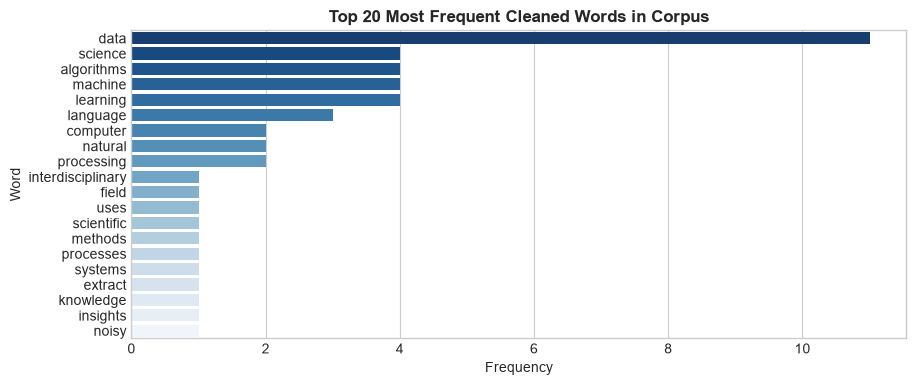

In [2]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_corpus(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    clean_tokens = [w for w in tokens if w not in stop_words]
    return tokens, clean_tokens

with open('sample_corpus.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

tokens_all, tokens_clean = preprocess_corpus(raw_text)

print(f"Total Raw Tokens : {len(tokens_all)}")
print(f"Cleaned Tokens  : {len(tokens_clean)}")

# Top 20 Most Frequent Words Plot
word_counts = Counter(tokens_clean)
top_20 = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 4))
sns.barplot(data=top_20, x='Frequency', y='Word', hue='Word', palette='Blues_r', legend=False)
plt.title('Top 20 Most Frequent Cleaned Words in Corpus', fontsize=12, fontweight='bold')
plt.show()

In [3]:
from nltk.util import ngrams

# 1. Bigram Model
bigrams = list(ngrams(tokens_all, 2))
bigram_model = defaultdict(Counter)

for w1, w2 in bigrams:
    bigram_model[w1][w2] += 1

# 2. Trigram Model
trigrams = list(ngrams(tokens_all, 3))
trigram_model = defaultdict(Counter)

for w1, w2, w3 in trigrams:
    trigram_model[(w1, w2)][w3] += 1

def predict_next_word(prefix_text, top_n=3):
    prefix_tokens = prefix_text.lower().split()
    
    # Try Trigram prediction first if 2+ words provided
    if len(prefix_tokens) >= 2:
        context = tuple(prefix_tokens[-2:])
        if context in trigram_model:
            predictions = trigram_model[context].most_common(top_n)
            return [w for w, count in predictions]
            
    # Fallback to Bigram prediction
    if len(prefix_tokens) >= 1:
        context = prefix_tokens[-1]
        if context in bigram_model:
            predictions = bigram_model[context].most_common(top_n)
            return [w for w, count in predictions]
            
    return ["<No Context Prediction>"]

# Test on 10 Prefixes
test_prefixes = ["data", "machine", "natural", "language", "computer", "sample", "search", "big", "training", "artificial"]
autocomplete_results = []

for prefix in test_prefixes:
    preds = predict_next_word(prefix, top_n=3)
    autocomplete_results.append({'Prefix': prefix, 'Top 3 Predictions': ", ".join(preds)})

df_autocomplete = pd.DataFrame(autocomplete_results)
print("=== AUTOCOMPLETE MODEL RESULTS ===")
print(df_autocomplete.to_string(index=False))

=== AUTOCOMPLETE MODEL RESULTS ===
    Prefix        Top 3 Predictions
      data   science, machine, data
   machine                 learning
   natural                 language
  language processing, autocomplete
  computer      algorithms, science
    sample                     data
    search                  engines
       big                     data
  training                     data
artificial             intelligence


In [4]:
def levenshtein_distance(str1, str2):
    m, n = len(str1), len(str2)
    dp = np.zeros((m + 1, n + 1), dtype=int)
    
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
        
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if str1[i-1] == str2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j],      # Deletion
                                   dp[i][j-1],      # Insertion
                                   dp[i-1][j-1])    # Substitution
    return dp[m][n]

vocabulary = set(tokens_all)

def autocorrect_word(word):
    if word in vocabulary:
        return word
    
    # Calculate edit distance against all vocab words
    distances = [(vocab_word, levenshtein_distance(word, vocab_word)) for vocab_word in vocabulary]
    distances.sort(key=lambda x: x[1])
    return distances[0][0]

# Test on 20 Misspelled Words
test_misspelled = [
    ("datta", "data"), ("sciens", "science"), ("machin", "machine"),
    ("lerning", "learning"), ("algoritm", "algorithm"), ("prosess", "process"),
    ("languag", "language"), ("computr", "computer"), ("mels", "models"),
    ("analyis", "analytics"), ("featur", "features"), ("search", "search"),
    ("tring", "training"), ("sampl", "sample"), ("extrac", "extract"),
    ("sysytem", "system"), ("knowledg", "knowledge"), ("nural", "natural"),
    ("minning", "mining"), ("experiens", "experience")
]

correct_count = 0
autocorrect_logs = []

for wrong, actual in test_misspelled:
    corrected = autocorrect_word(wrong)
    is_correct = (corrected == actual)
    if is_correct:
        correct_count += 1
    autocorrect_logs.append({'Input': wrong, 'Expected': actual, 'Predicted': corrected, 'Match': is_correct})

df_autocorrect = pd.DataFrame(autocorrect_logs)
accuracy = (correct_count / len(test_misspelled)) * 100
print(f"Autocorrect Accuracy: {accuracy:.2f}%\n")
print(df_autocorrect.head(10).to_string(index=False))

Autocorrect Accuracy: 80.00%

   Input  Expected  Predicted  Match
   datta      data       data   True
  sciens   science    science   True
  machin   machine    machine   True
 lerning  learning   learning   True
algoritm algorithm algorithms  False
 prosess   process   projects  False
 languag  language   language   True
 computr  computer   computer   True
    mels    models     models   True
 analyis analytics  analytics   True


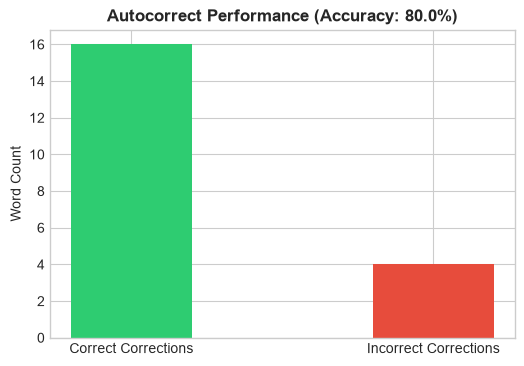

In [5]:
# Accuracy & Error Summary Chart
labels = ['Correct Corrections', 'Incorrect Corrections']
sizes = [correct_count, len(test_misspelled) - correct_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color=['#2ecc71', '#e74c3c'], width=0.4)
plt.title(f'Autocorrect Performance (Accuracy: {accuracy:.1f}%)', fontsize=12, fontweight='bold')
plt.ylabel('Word Count')
plt.show()

## Production Systems vs. Naive Implementation Discussion

1. **Context-Aware Correction:** Modern keyboards (e.g., Gboard) utilize Transformer-based language models (BERT/LSTM) to evaluate sentence-level context rather than calculating static word-level edit distances.
2. **Key Spatial Proximity:** Real-world autocorrect incorporates QWERTY keyboard layout metrics—assigning lower penalty weights to adjacent keys (e.g., mistyping `o` instead of `i`).
3. **Scalability & Latency:** Real-world systems store prefix trees (**Tries**) in memory to perform sub-millisecond autocomplete lookups across millions of n-gram variations.